# LSTM(Long Short Term Memory) Hands-On On `Tesla` Dataset

> Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from warnings import filterwarnings
filterwarnings('ignore')

#### Load the dataset

In [2]:
df = pd.read_csv('/content/Tesla.csv.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [3]:
# Info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


* Date data-type should be datetime formate

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1692 non-null   datetime64[ns]
 1   Open       1692 non-null   float64       
 2   High       1692 non-null   float64       
 3   Low        1692 non-null   float64       
 4   Close      1692 non-null   float64       
 5   Volume     1692 non-null   int64         
 6   Adj Close  1692 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 92.7 KB


1. **Open:** The opening price of the stock on a particular trading day.

2. **High:** The highest price at which the stock traded during the `trading day`.

3. **Low:** The lowest price at which the stock traded during the `trading day`.

4. **Close:** The closing price of the stock for the day.

5. **Volume:** The total number of shares or contracts traded for the stock during the trading day. It reflects the level of activity or liquidity for the stock.

6. **Adj Close (Adjusted Close):** This is the closing price adjusted for corporate actions like `stock splits`, `dividends`, and `new stock offerings`.

In [6]:
# Checking for the null values
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


In [7]:
# Checking for the duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
# Statistical analysis
df.describe()

,Date,Open,High,Low,Close,Volume,Adj Close
count,1692,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,2013-11-06 02:53:37.021276416,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,2012-03-01 18:00:00,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,2013-11-05 12:00:00,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,2015-07-14 06:00:00,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,2017-03-17 00:00:00,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009
std,NaN,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187


### Plot the `open price` distribution

In [11]:
fig = px.histogram(df, x='Open', nbins=50, title='<b>Distribution of Open Price</b>')
fig.update_layout(xaxis_title='Open Price', yaxis_title='Frequency')
fig.show()

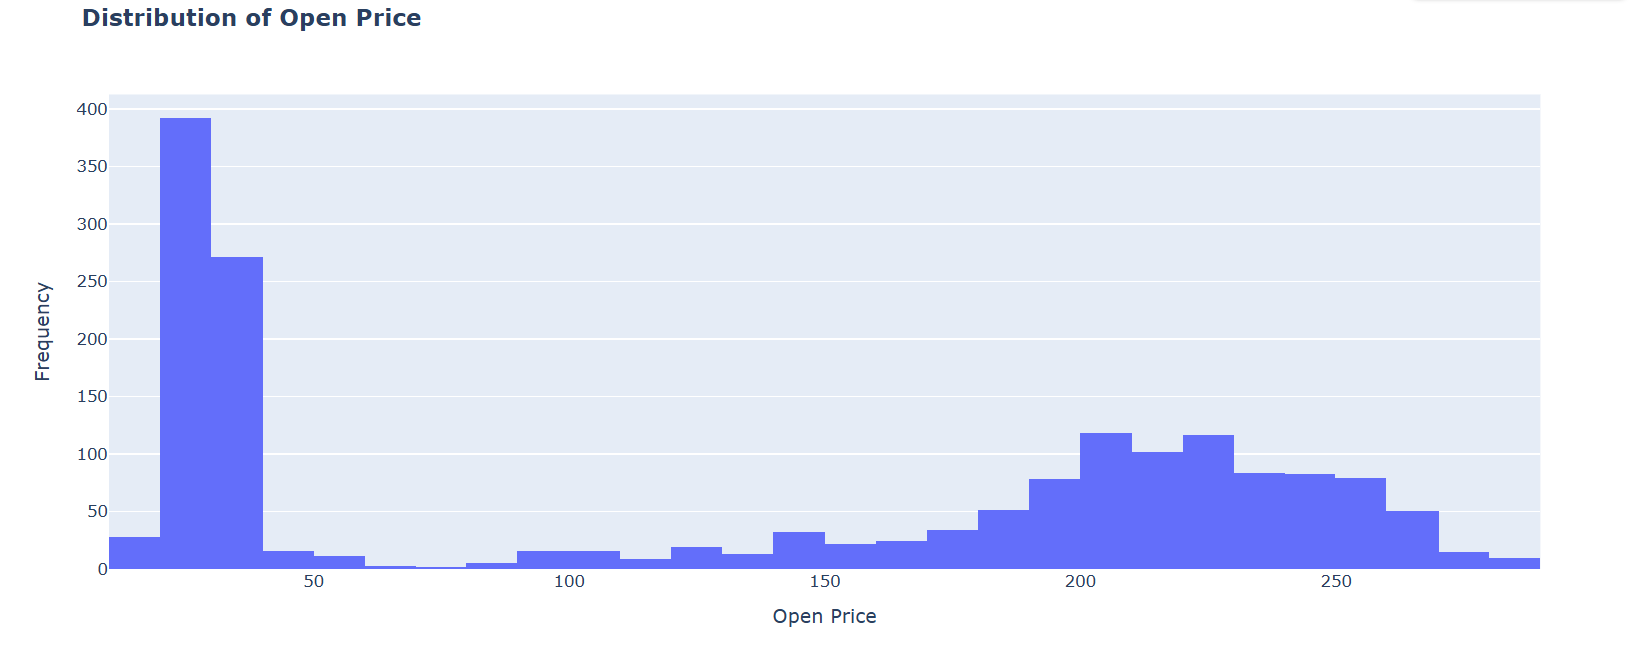

### Plot the `low` vs `high`

In [13]:
fig = px.line(df, x='Date', y=['Low', 'High'], title='Low vs High Price', labels={'Date': 'Date', 'value': 'Price'})
fig.update_traces(line=dict(color='red'), selector=dict(name='Low'))
fig.update_traces(line=dict(color='forestgreen'), selector=dict(name='High'))
fig.update_layout(xaxis_title='Date', yaxis_title='Price')
fig.show()

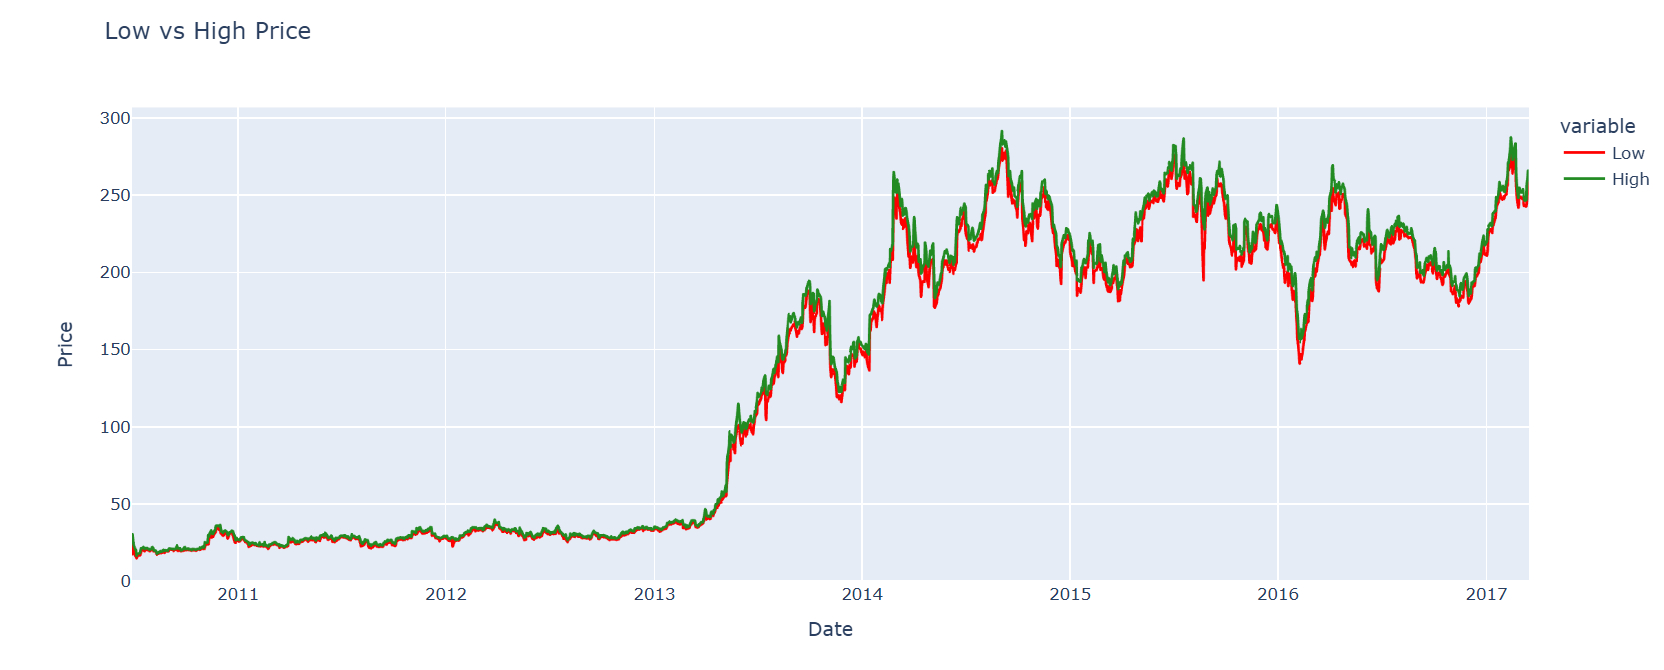

###  Splitting the `Tesla data` into `training` and `testing` sets

Train ratio: 70
Test ration: 30

In [14]:
len_train_data = round(len(df) * 0.7)
len_test_data = round(len(df) * 0.3)

In [15]:
len_test_data

508

In [16]:
len_train_data

1184

In [17]:
train_data = df[:len_train_data].iloc[:,:2]
train_data

,Date,Open
0,2010-06-29,19.000000
1,2010-06-30,25.790001
2,2010-07-01,25.000000
3,2010-07-02,23.000000
4,2010-07-06,20.000000
...,...,...
1179,2015-03-06,199.210007
1180,2015-03-09,194.389999
1181,2015-03-10,188.460007
1182,2015-03-11,191.149994


In [27]:
test_data = df[len_train_data:].iloc[:,:2]
test_data

,Date,Open
1184,2015-03-13,188.949997
1185,2015-03-16,192.000000
1186,2015-03-17,195.429993
1187,2015-03-18,194.960007
1188,2015-03-19,202.000000
...,...,...
1687,2017-03-13,244.820007
1688,2017-03-14,246.110001
1689,2017-03-15,257.000000
1690,2017-03-16,262.399994


In [28]:
open_train_data = train_data.Open.values
open_train_data = open_train_data.reshape(-1,1)

In [29]:
open_train_data

array([[ 19.      ],
       [ 25.790001],
       [ 25.      ],
       ...,
       [188.460007],
       [191.149994],
       [193.75    ]])

In [30]:
open_test_data = test_data.Open.values
open_test_data = open_test_data.reshape(-1,1)

In [31]:
open_test_data[:5]

array([[188.949997],
       [192.      ],
       [195.429993],
       [194.960007],
       [202.      ]])

# Normalization/Feature Scaling

* dataset values will be in between `0` and `1` after scaling

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))


In [34]:
scaled_train_data = scaler.fit_transform(open_train_data)
scaled_test_data = scaler.transform(open_test_data)


In [36]:
scaled_train_data.min(), scaled_train_data.max()


(np.float64(0.0), np.float64(1.0))

In [37]:
scaled_test_data.min(), scaled_test_data.max()

(np.float64(0.4647000386483978), np.float64(0.9728942856387139))

visualize the `line chart` for `Tesla` Stock Open Price

#### Before Scaling the data

In [38]:
fig = px.line(open_train_data, title='<b>Tesla Stock Open Price before scaling</b>')
fig.update_layout(xaxis_title="<b>Trading Days as 1,2,3,4,---</b>", yaxis_title='<b>Open Price</b>')
fig.update_traces(name='Train Data', line=dict(color='blue'))
fig.show()

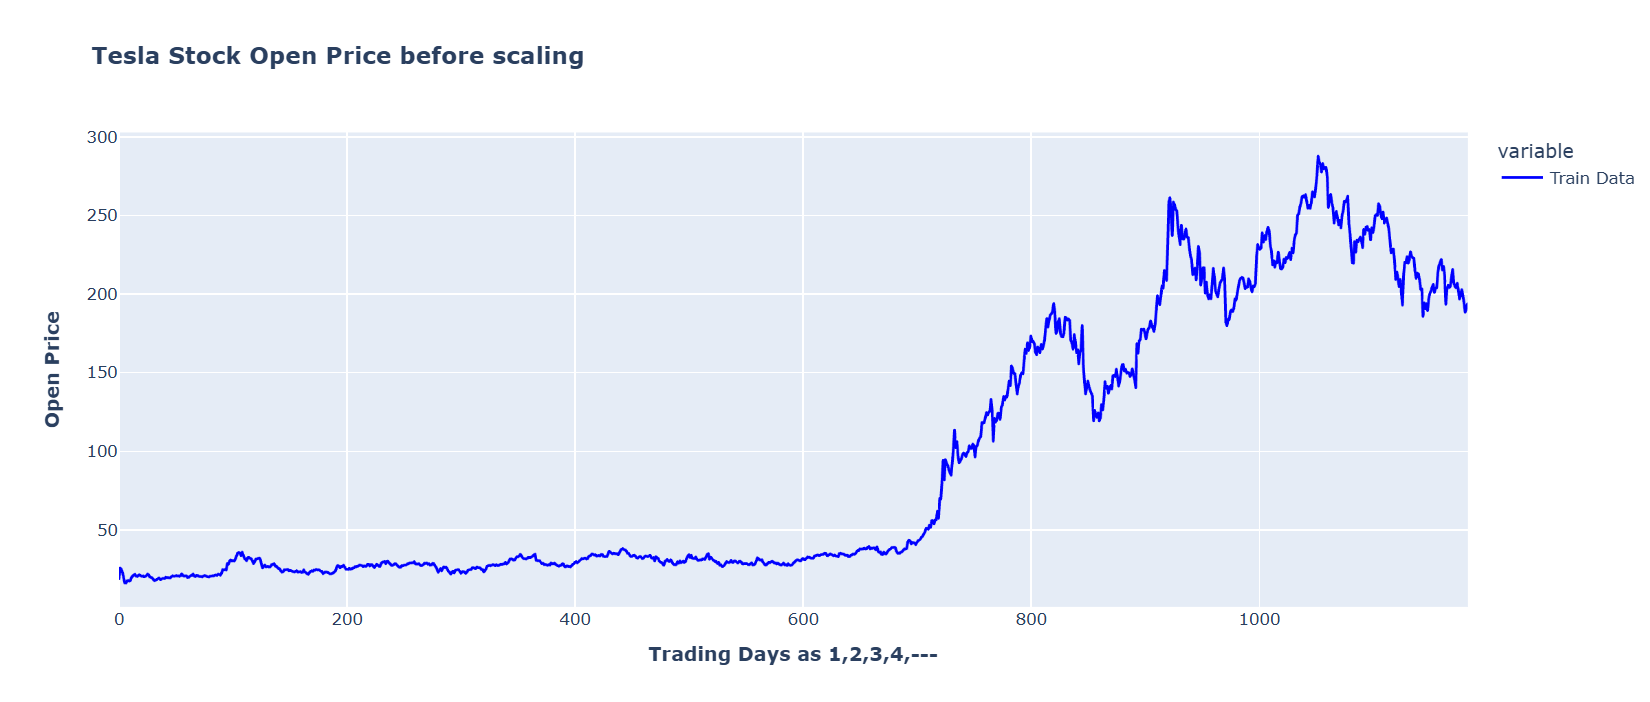

In [41]:
fig = px.line(open_test_data, title='<b>Tesla Stock Open Price before scaling</b>')
fig.update_layout(xaxis_title="<b>Trading Days as 1,2,3,4,---</b>", yaxis_title='<b>Open Price</b>')
fig.update_traces(name='Test Data', line=dict(color='purple'))
fig.show()

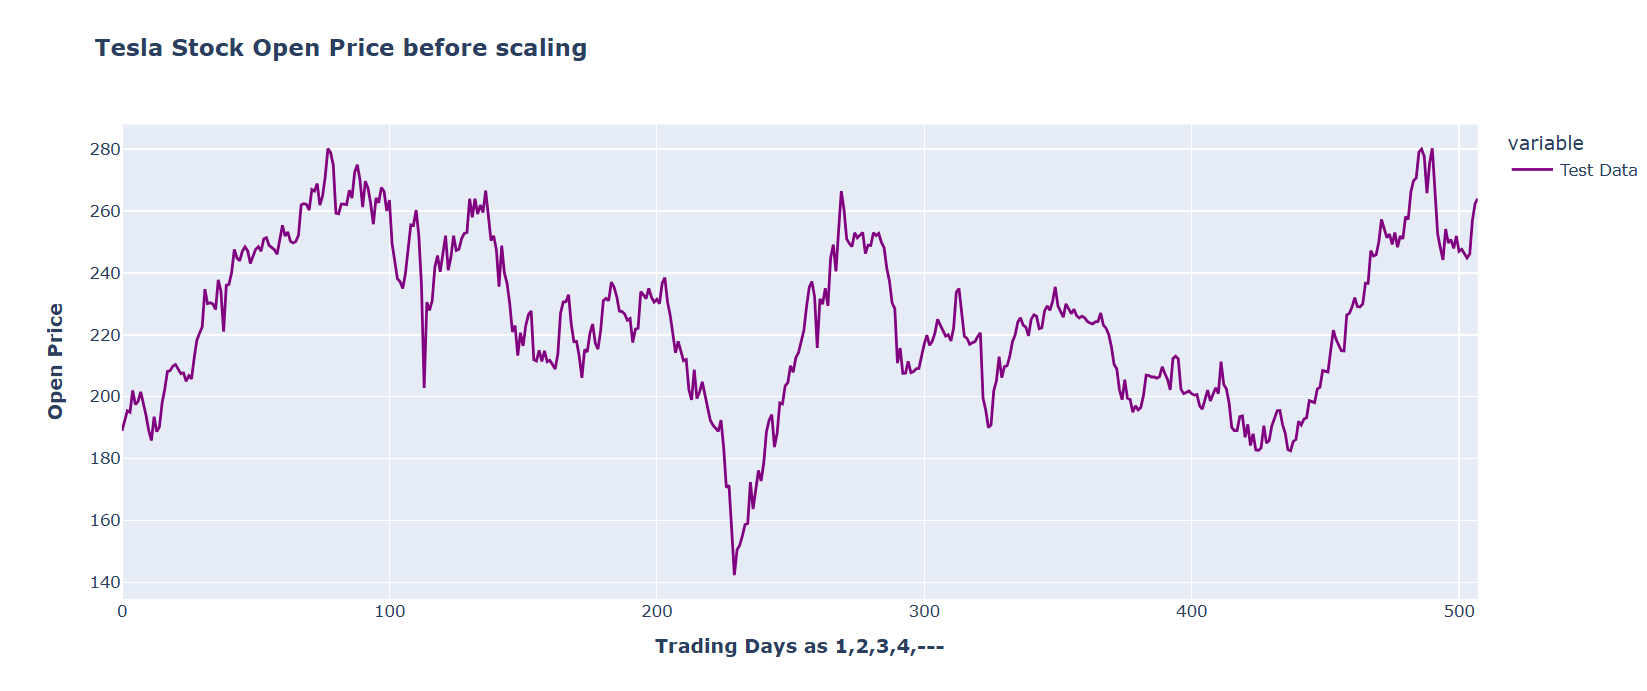

#### After Scaling

In [44]:
fig = px.line(scaled_train_data, title='<b>Tesla Stock Open Price after scaling</b>')
fig.update_layout(xaxis_title="<b>Trading Days as 1,2,3,4,---</b>", yaxis_title='<b>Open Price</b>')
fig.update_traces(name='Scaled Train Data', line=dict(color='blue'))
fig.show()

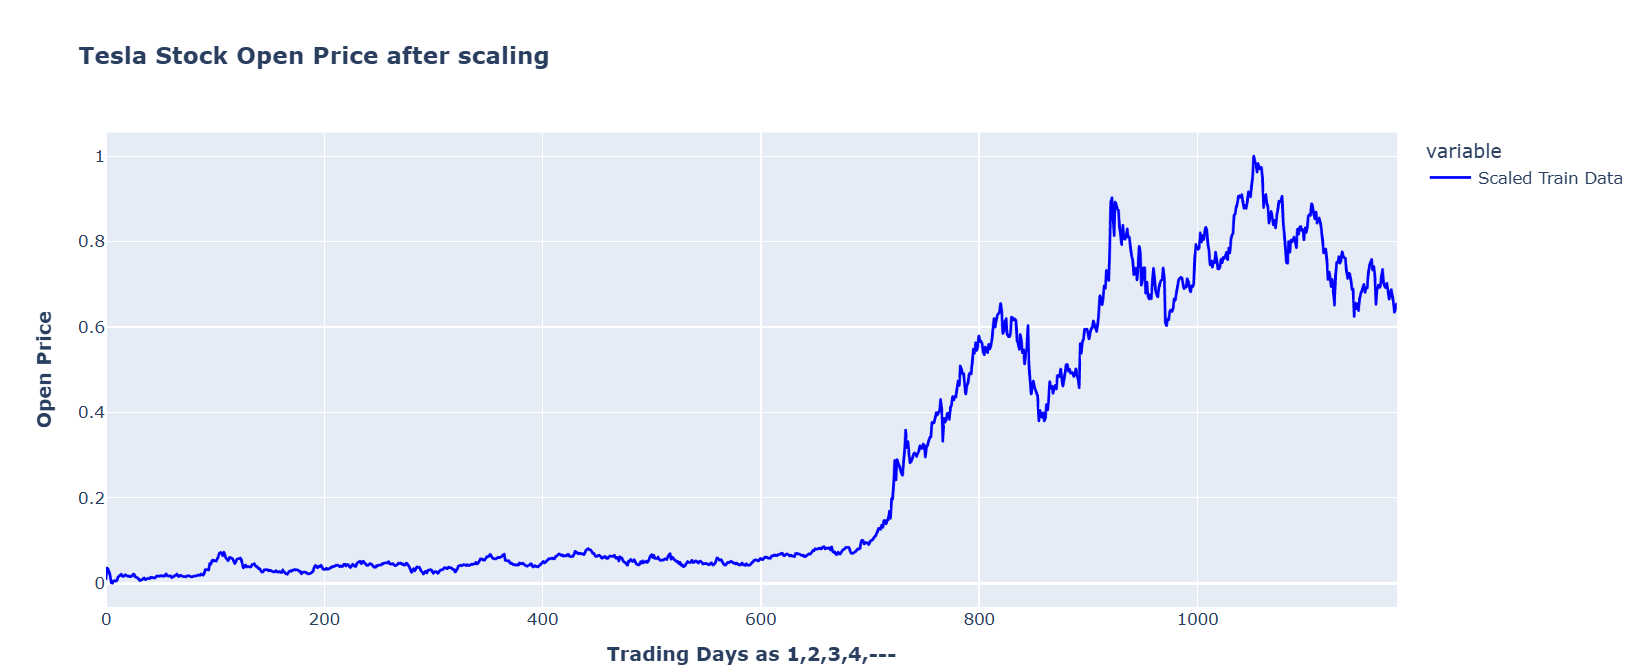

In [43]:
fig = px.line(scaled_test_data, title='<b>Tesla Stock Open Price After scaling</b>')
fig.update_layout(xaxis_title="<b>Trading Days as 1,2,3,4,---</b>", yaxis_title='<b>Open Price</b>')
fig.update_traces(name='Scaled Test Data', line=dict(color='purple'))
fig.show()

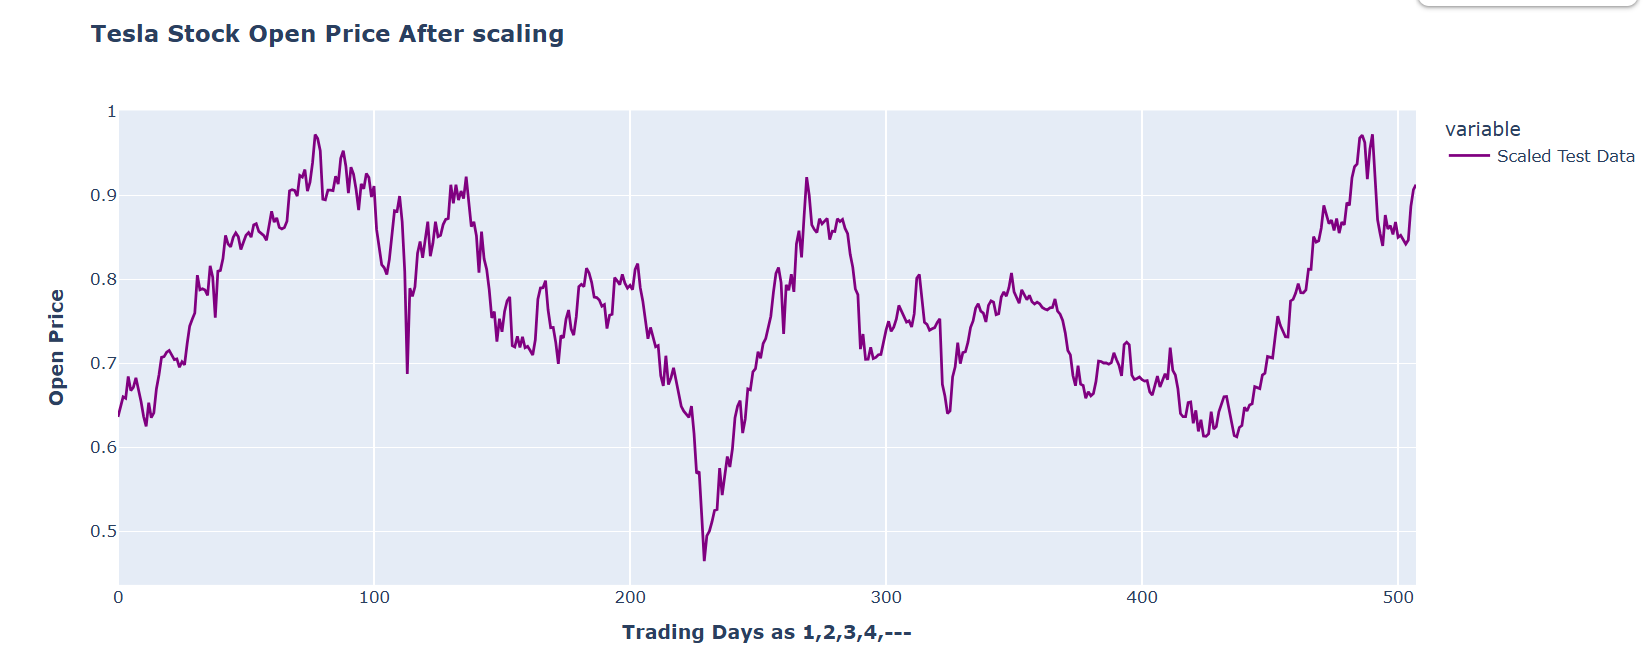

In [144]:
X_train = []
Y_train = []
time_steps = 50
for i in range(time_steps,len_train_data):
    X_train.append(scaled_train_data[i-time_steps: i,0])
    Y_train.append(scaled_train_data[i,0])

In [145]:
# Convert list into array
X_train, Y_train = np.array(X_train), np.array(Y_train)

In [146]:
print("Shape of X_train before reshape:", X_train.shape)
print("Shape of y_train before reshape:", Y_train.shape)

Shape of X_train before reshape: (1134, 50)
Shape of y_train before reshape: (1134,)


In [147]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
Y_train = np.reshape(Y_train, (Y_train.shape[0], 1))

### 5. Build the `LSTM` model

In [148]:
from keras import Sequential
from keras.layers import LSTM
from keras.layers import Dense,Dropout

In [149]:
Lstm = Sequential()
Lstm

<Sequential name=sequential_5, built=False>

In [150]:
### Adding the first RNN layer and also the drop regularization
Lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
### Second LSTM Layer
Lstm.add(
    LSTM(64, return_sequences= True))
Lstm.add(Dropout(0.2))
### third LSTM Layer
Lstm.add(
    LSTM(64, return_sequences= False))
### Adding Dense Layers
Lstm.add(Dense(32))
### Output Layer with single neuron
Lstm.add(Dense(1))
### Compiling the model
Lstm.compile(loss="mean_squared_error", optimizer ="adam", metrics = ["accuracy"])


In [151]:
History = Lstm.fit(X_train, Y_train, epochs=50, batch_size=32)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - accuracy: 0.0018 - loss: 0.0436
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 6.9467e-04 - loss: 0.0020
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 1.2223e-04 - loss: 0.0022
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.0018 - loss: 0.0022
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 9.6639e-05 - loss: 0.0019
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.0015 - loss: 0.0022
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.0023 - loss: 0.0018
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 5.5361e-04 - loss: 0.0016
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.0015 - loss: 0.0017
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.0027 - loss: 0.0017
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.0018 - loss: 0.0019
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 

In [155]:
y_train_pred = Lstm.predict(X_train)

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


In [156]:
y_train_pred = scaler.inverse_transform(y_train_pred)

In [157]:
y_train_pred.min(), y_train_pred.max()

(np.float32(19.786703), np.float32(282.16168))

In [159]:
Y_train = scaler.inverse_transform(Y_train)

In [160]:
Y_train.min(),Y_train.max()

(np.float64(19.889999), np.float64(287.67001300000004))

### Let us visualize the actual vs predicted for `training`

In [161]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=Y_train.flatten(), name="Actual",mode='lines'))
fig.add_trace(go.Scatter(y=y_train_pred.flatten(), name="Predicted",mode='lines'))
fig.update_layout(
    title="Actual vs Predicted Training data",
    xaxis_title="Time",
    yaxis_title="Price")
fig.update_traces(line=dict(color='indigo'),selector=dict(name='Actual'))
fig.update_traces(line=dict(color='darkorange'),selector=dict(name='Predicted'))
fig.show()

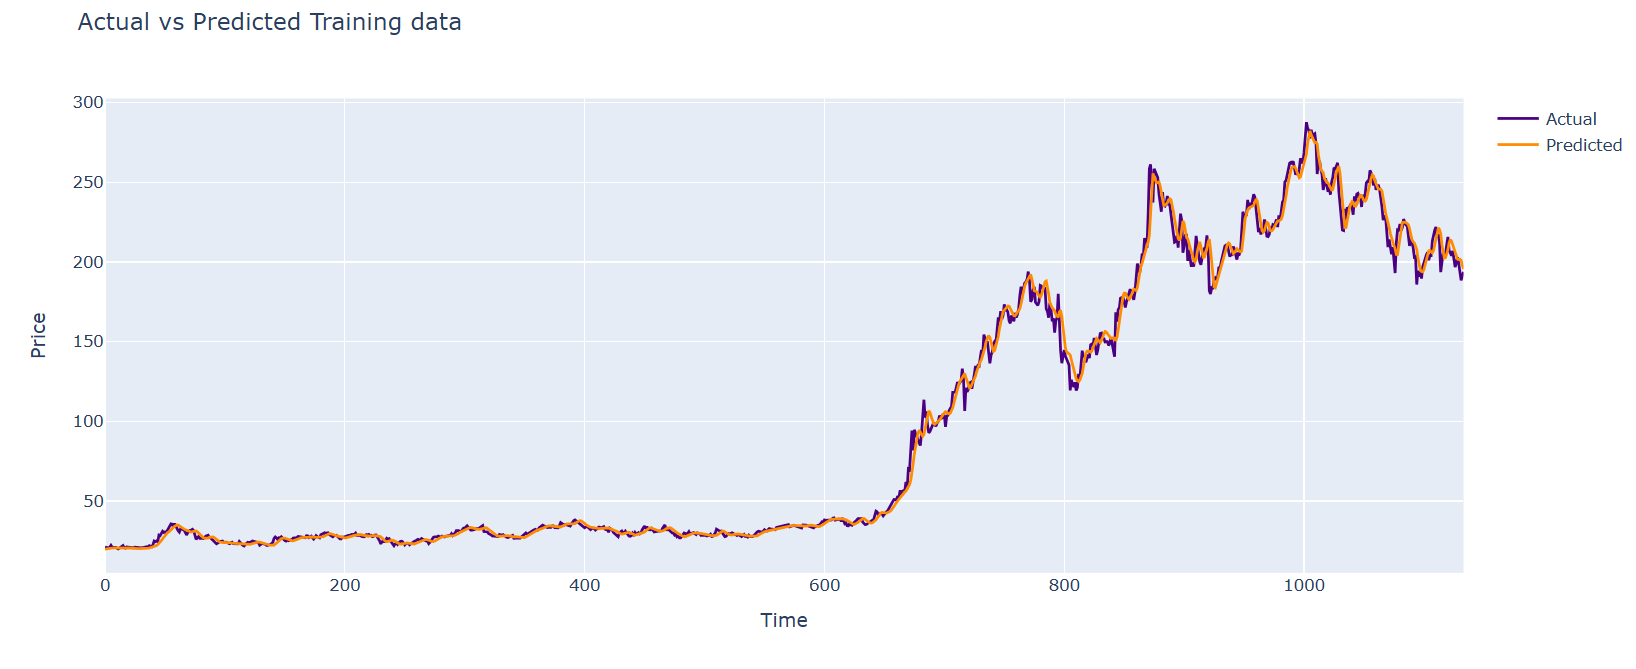

In [162]:
X_test = []
Y_test = []
for i in range(time_steps,len_test_data):
  X_test.append(scaled_test_data[i-time_steps:i,0])
  Y_test.append(scaled_test_data[i,0])

In [163]:
X_test , Y_test = np.array(X_test) , np.array(Y_test)

In [164]:
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",Y_test.shape)

Shape of X_test before reshape : (458, 50)
Shape of y_test before reshape : (458,)


In [165]:
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
Y_test = np.reshape(Y_test,(Y_test.shape[0],1))

In [166]:
print("Shape of X_test after reshape :",X_test.shape)
print("Shape of y_test after reshape :",Y_test.shape)

Shape of X_test after reshape : (458, 50, 1)
Shape of y_test after reshape : (458, 1)


In [168]:
Y_test = scaler.inverse_transform(Y_test)

In [170]:
y_test_pred = Lstm.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [171]:
y_test_pred.min(),y_test_pred.max()

(np.float32(0.5032034), np.float32(0.9573942))

In [172]:
y_test_pred = scaler.inverse_transform(y_test_pred)

In [173]:
y_test_pred.min(),y_test_pred.max()

(np.float32(152.77481), np.float32(276.10126))

In [169]:
Y_test.min(),Y_test.max()

(np.float64(142.320007), np.float64(280.309998))

### Let us visualize the actual vs predicted for `Testing`

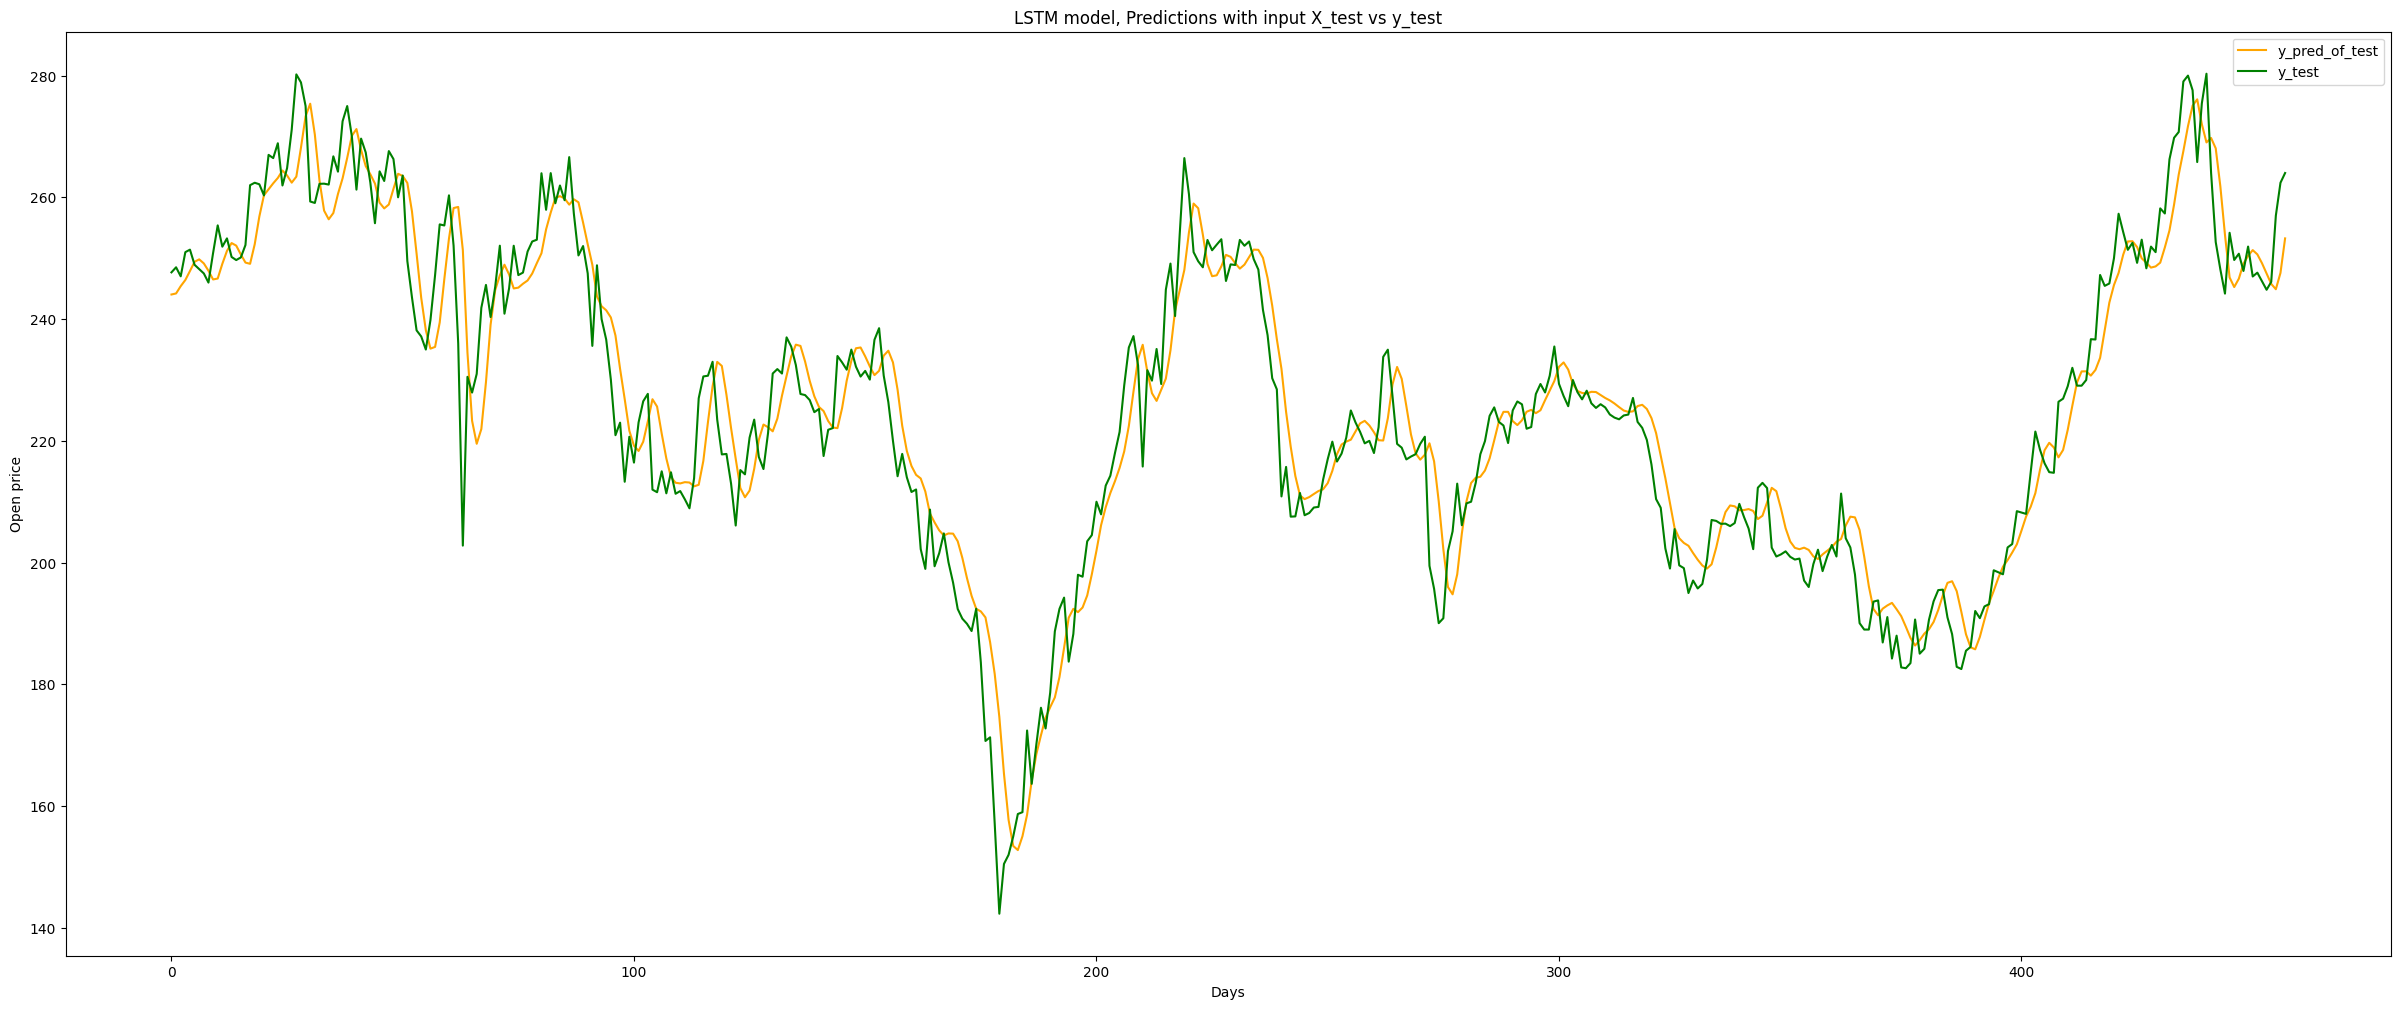

In [180]:
plt.subplots(figsize =(30,12))
plt.plot(y_test_pred, label = "y_pred_of_test", c = "orange" )
plt.plot(Y_test, label = "y_test", color = "g")
plt.xlabel("Days")
plt.ylabel("Open price")
plt.title("LSTM model, Predictions with input X_test vs y_test")
plt.legend()
plt.show()

In [183]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=Y_test.flatten(),mode='lines',name='Actual'))
fig.add_trace(go.Scatter(y=y_test_pred.flatten(),mode='lines',name='Predicted'))
fig.update_layout(
    title='Actual vs Predicted',
    xaxis_title='Time',
    yaxis_title='Price',
    width=1200,
    height=300)
fig.update_traces(line=dict(color='indigo'),selector=dict(name='Actual'))
fig.update_traces(line=dict(color='red'),selector=dict(name='Predicted'))
fig.show()

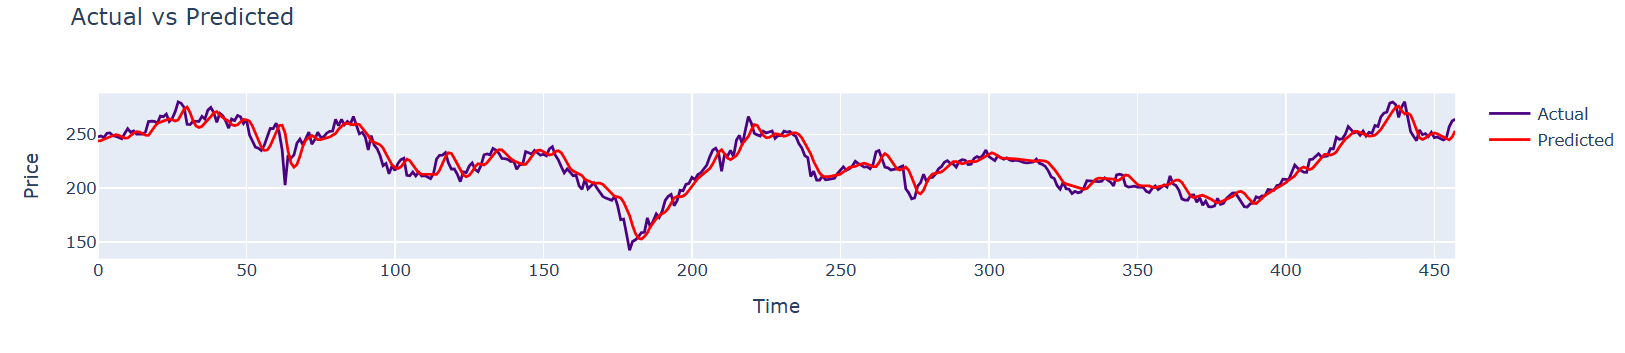

# Open price prediction with LSTM-Model





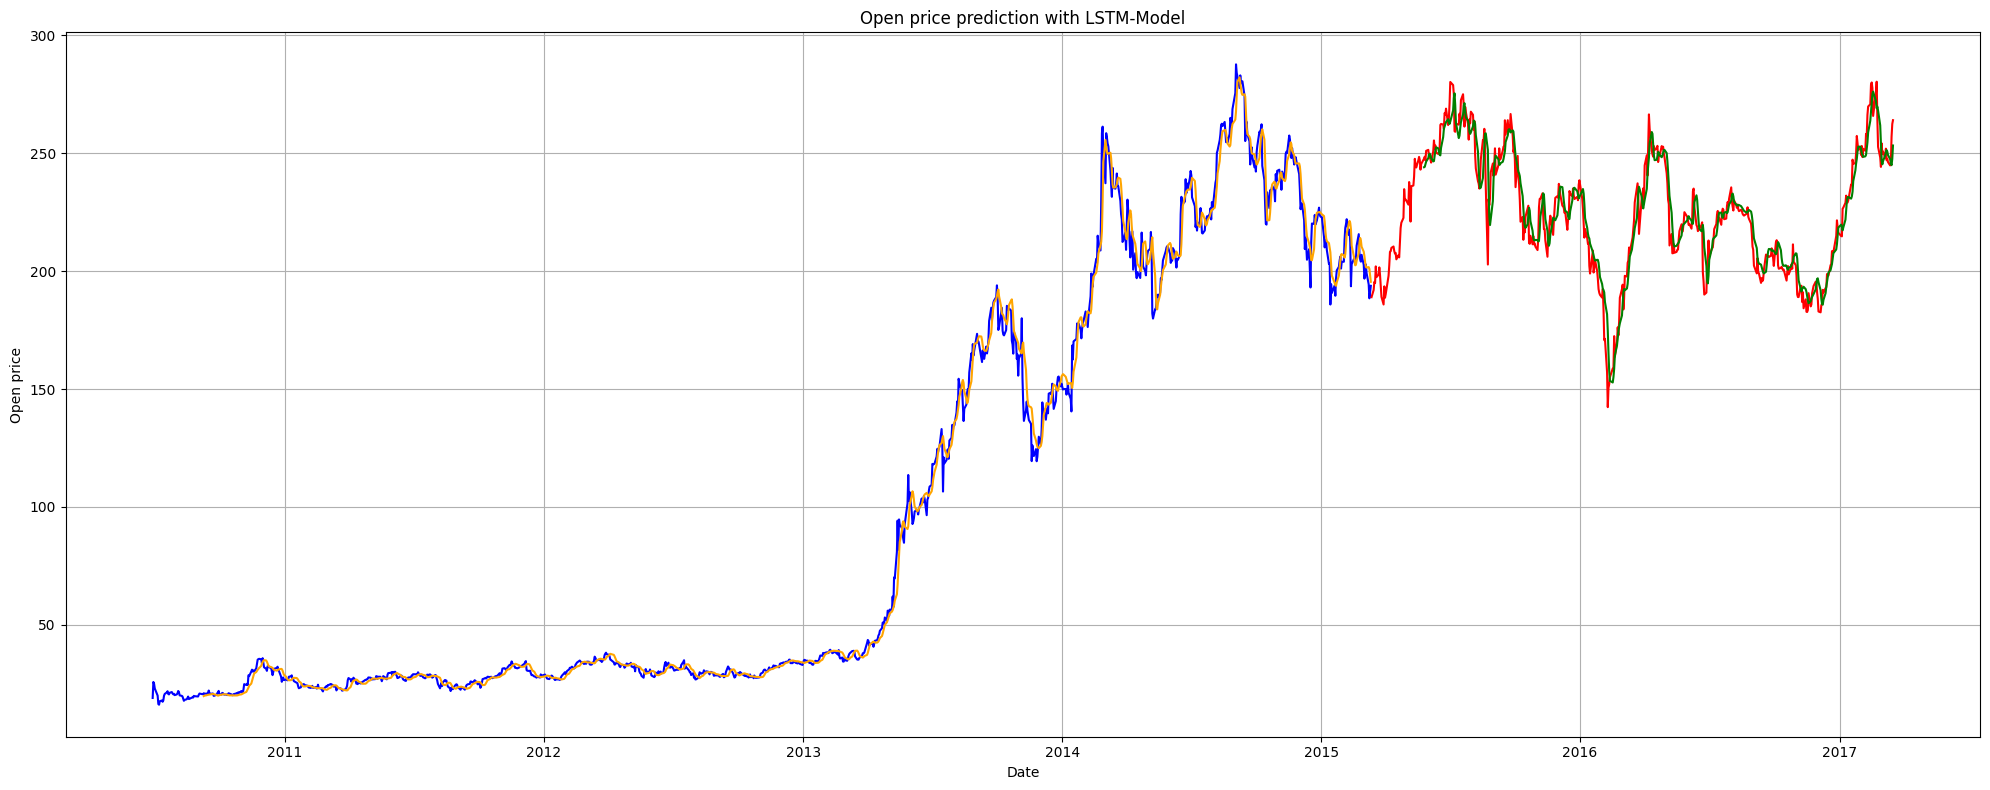

In [186]:
plt.figure(figsize=(20,8))
plt.plot(train_data.Date,train_data.Open,label='Training data',color='blue')
plt.plot(test_data.Date,test_data.Open,label='Testing data',color='red')
plt.plot(train_data.Date.iloc[time_steps:],y_train_pred,label='Training data prediction',color='orange')
plt.plot(test_data.Date.iloc[time_steps:],y_test_pred,label='Testing data prediction',color='green')
plt.title('Open price prediction with LSTM-Model')
plt.xlabel('Date')
plt.ylabel('Open price')
plt.tight_layout()
plt.grid(True)
plt.show()

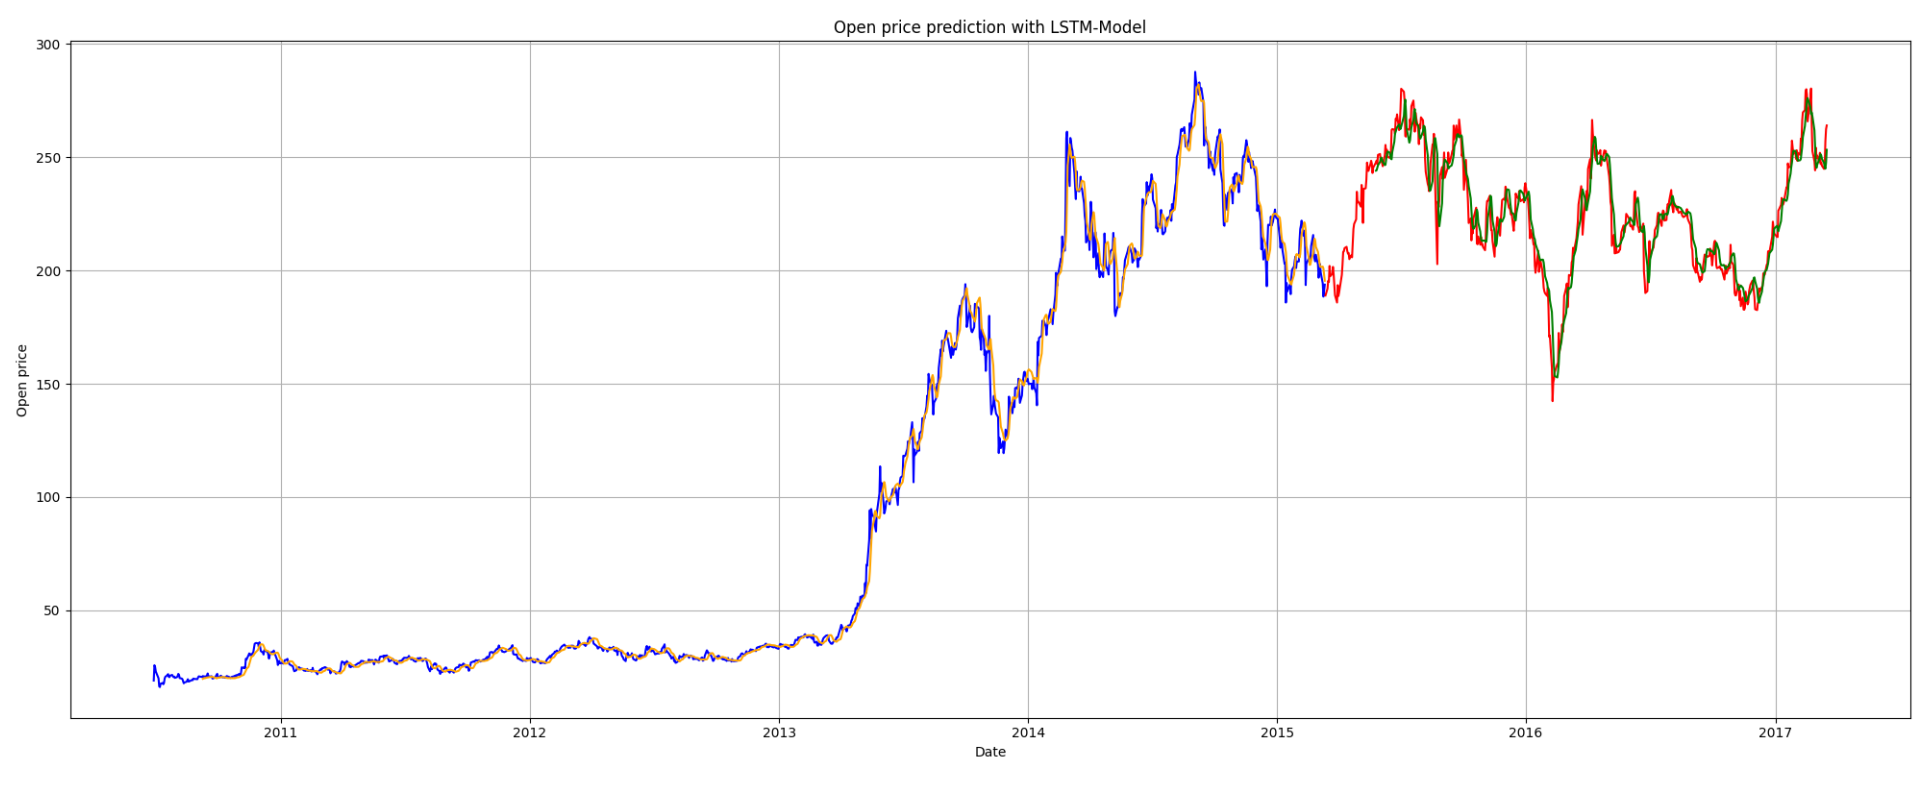

# Prediction Difference between `RNN-Model` and `LSTM-Model`

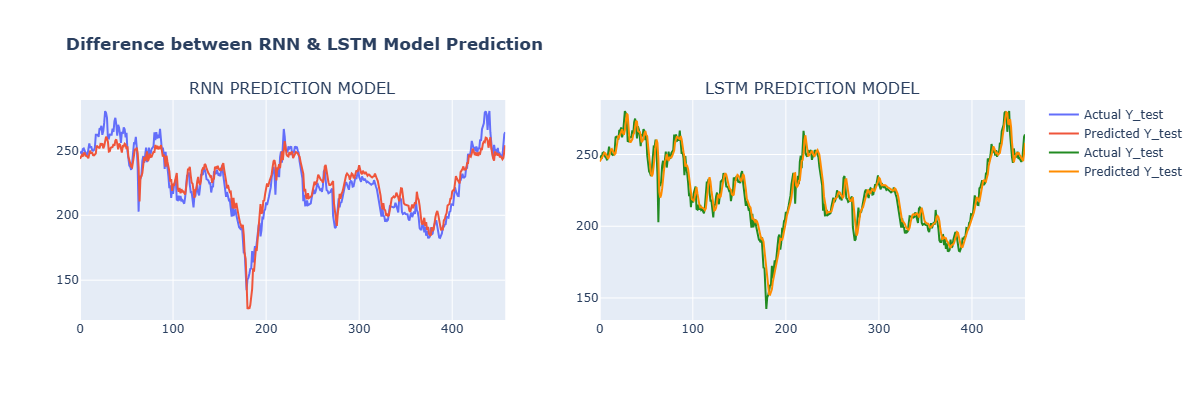